<a href="https://colab.research.google.com/github/sungfeliks/Sentiment-Analysis-of-Free-Meal-Program-in-Indonesia/blob/main/Sentiment_Analysis_Free-Meal-Program-Indonesia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Upload Dataset Langsung**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Data_Sentimen_MBG.csv to Data_Sentimen_MBG.csv


# **Persiapan Library**

In [3]:
# Install semua library yang kira-kira dibutuhkan, kalau ada yang kurang, bisa diinstall di cell selanjutnya kalau terlupakan
!pip install -q transformers datasets scikit-learn matplotlib seaborn tqdm pandas numpy tensorboard torch nltk

In [4]:
# Import semua librarynya
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re, os, time
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback, pipeline
)
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from datasets import Dataset as HfDataset

# Cek GPU (Pastikan CUDA-nya available, biar lebih cepat proses trainingnya)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Buat folder untuk menyimpan model & hasil (penting untuk pengumpulan nanti)
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("logs/tensorboard", exist_ok=True)

Device: cuda


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **Baca Dataset**

In [5]:
# Baca file csv
df = pd.read_csv('Data_Sentimen_MBG.csv') #Disclaimer: Saya tidak memiliki maksud untuk mennyindir pihak tertentu, dataset murni untuk pengerjaan proyek saja.
print("Shape awal:", df.shape)
df.head()

Shape awal: (6419, 5)


,author,published_at,like_count,text,public
0,@Ipank049,2026-03-15T19:00:49Z,0,Penguasa dan Pelaksana Program MBG menjadi Pen...,True
1,@Tmsaja873,2026-03-15T11:15:42Z,0,anaknya makan 1x bapaknya penganguran..,True
2,@fakhrieofisial4819,2026-03-15T07:36:34Z,0,"Rusak lah negara kalau Nepotisme, korupsi sema...",True
3,@sudaryadidar1358,2026-03-14T08:23:35Z,0,Programpresiden jokowi. Berobat gratid banyak ...,True
4,@KokGiniAmat,2026-03-14T06:33:38Z,0,Maling Berkedok Gizi,True


In [6]:
print(df["text"].sample(3).values)

['Dari dulu makan bergizi gratis saya tdk setuju,bikin program sekolah gratis dari SD sampe kuliah bila perlu,,jadi yg ga punya masalah biaya bisa sekolah tinggi,ini program bukanya bikin bagus malah bnyak yg di rugikan,,'
 'Peoyek buang2 uang anj'
 'sampai muak, pemerintah seperti ini, tidak bisa meberi contoh yang baik kepada masyarakat, yang ada hanya korupsi, tidak ada prestasi, sekarang korupsi merajalela turun kemasyarakat bawah.']


# **Preprocessing Teks**

In [7]:
stop_words_id = set(stopwords.words('indonesian'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words_id]
    return " ".join(tokens)

df['clean_text'] = df["text"].apply(clean_text)

# Simpan juga versi tanpa stopword removal untuk BERT (hanya lowercase)
df['bert_text'] = df["text"].apply(lambda x: str(x).lower())

# Buang komentar yang setelah dibersihkan panjangnya <= 2 kata
df = df[df['clean_text'].str.split().str.len() > 2].reset_index(drop=True)
print("Shape setelah bersih:", df.shape)

Shape setelah bersih: (5639, 7)


# **Definisikan Lexicon**

In [8]:
negative_words = {
    'korupsi','korup','koruptor','bubarkan','hancur','parah','sengsara',
    'bangsat','edan','jijik','mampus','busuk','basi','gagal','bohong',
    'ngibul','pembohong','penipu','penjarakan','turunkan','ganti',
    'bencana','rugi','babak belur','berantakan','kacau','tolol','bodoh',
    'bego','gila','sampah','bajingan','penghianat','maling','pencuri',
    'rezim','penguasa','otoriter','cawe','bagi-bagi','bancakan',
    'proyek','proyek mbg','bagi kue','kroni','oligarki','markus',
    'pencitraan','bohongin','tipu','akal-akalan','goreng','kebohongan',
    'penderitaan','rakyat sengsara','uang rakyat','apbn bocor','teko',
    'teko bocor','berantas','hentikan','stop','musnahkan','enyah',
    'tendang','lengser','gagal total','bobrok','amburadul','ngaco',
    'ngawur','permainan','mainan','dagelan','lawak','komedi',
    'sandal jepit','prabowo','gemoy','wowo','wiwi' # konteks lokal
}

positive_words = {
    'terima kasih','bagus','sehat','manfaat','membantu','sukses',
    'lanjutkan','setuju','dukung','hebat','pintar','cerdas','solusi',
    'sejahtera','makmur','gratis','berkualitas','baik','peduli',
    'bangga','harapan','yakin','percaya','patriotik','jaya',
    'berhasil','mantap','luar biasa','keren','top','kagum',
    'mensejahterakan','menyehatkan','bergizi','bantuan','program',
    'presiden','prabowo','lanjutkan','jokowi','maju','indonesia',
    'makan gratis','anak sehat','pendidikan','sekolah','cerdas'
}

def lexicon_label(text):
    text_lower = text.lower()
    # Cek kata/frasa negatif (prioritas)
    for phrase in negative_words:
        if phrase in text_lower:
            return 2  # negatif
    # Cek positif
    for phrase in positive_words:
        if phrase in text_lower:
            return 1  # positif
    return None  # tidak ditemukan

# **Auto‑Labeling Sentimen dengan mdhugol/indonesia-ber**

In [9]:
classifier = pipeline(
    "sentiment-analysis",
    model="mdhugol/indonesia-bert-sentiment-classification",
    return_all_scores=True
)
label_map = {'LABEL_0': 2, 'LABEL_1': 0, 'LABEL_2': 1}

def auto_label_and_confidence(text):
    try:
        scores = classifier(text[:512])[0]
        top = max(scores, key=lambda x: x['score'])
        return label_map[top['label']], top['score']
    except:
        return 0, 0.0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

# **Combined Labeling**

In [10]:
def combined_label(text):
    lex = lexicon_label(text)
    if lex is not None:
        return lex, 1.0  # confidence penuh
    else:
        return auto_label_and_confidence(text)

# Jalankan labeling
results = df['clean_text'].apply(combined_label)
df['label'] = results.apply(lambda x: x[0])
df['confidence'] = results.apply(lambda x: x[1])

print("Distribusi label (setelah lexicon + auto-label):")
print(df['label'].value_counts())
print("Rata-rata confidence:", df['confidence'].mean())

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Distribusi label (setelah lexicon + auto-label):
label
2    2458
0    1782
1    1399
Name: count, dtype: int64
Rata-rata confidence: 0.6839865224330555


# **Visualisasi Distribusi**

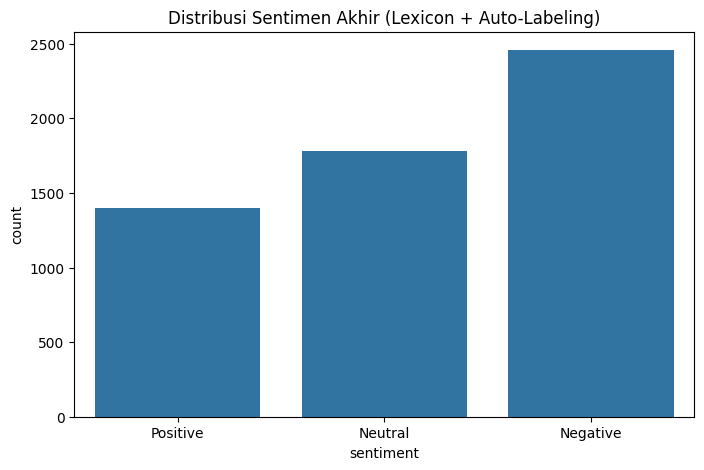

In [11]:
class_names = {0: "Neutral", 1: "Positive", 2: "Negative"}
df['sentiment'] = df['label'].map(class_names)

plt.figure(figsize=(8,5))
sns.countplot(x='sentiment', data=df, order=['Positive','Neutral','Negative'])
plt.title("Distribusi Sentimen Akhir (Lexicon + Auto-Labeling)")
plt.savefig("results/sentiment_distribution.png")
plt.show()

# **Siapkan Data untuk GRU (Tokenisasi & Padding)**

In [12]:
def build_vocab(texts, max_vocab=15000):
    counter = Counter()
    for t in texts: counter.update(t.split())
    vocab = {'<PAD>':0, '<UNK>':1}
    for w, _ in counter.most_common(max_vocab):
        vocab[w] = len(vocab)
    return vocab

vocab = build_vocab(df['clean_text'], max_vocab=15000)
vocab_size = len(vocab)
max_len = 60

def encode_text(text):
    ids = [vocab.get(t, 1) for t in text.split()[:max_len]]
    return ids + [0]*(max_len - len(ids))

df['encoded'] = df['clean_text'].apply(encode_text)

X = np.array(df['encoded'].tolist())
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4511, 60) Test: (1128, 60)


# **DataLoader untuk GRU**

In [13]:
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

batch_size = 64
train_loader = DataLoader(SentimentDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(SentimentDataset(X_test, y_test), batch_size=batch_size)

# **Model GRU + Attention**

In [14]:
class AttentionGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim=200, hidden_dim=256, output_dim=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(hidden_dim*2, 1)
        self.fc = nn.Linear(hidden_dim*2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)
        outputs, _ = self.gru(x)
        attn = torch.softmax(self.attention(outputs).squeeze(-1), dim=1)
        context = torch.sum(outputs * attn.unsqueeze(-1), dim=1)
        return self.fc(self.dropout(context))

model_gru = AttentionGRU(vocab_size).to(device)
print(model_gru)

AttentionGRU(
  (embedding): Embedding(12530, 200, padding_idx=0)
  (gru): GRU(200, 256, batch_first=True, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=True)
  (fc): Linear(in_features=512, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


# **Training GRU dengan Class Weight & TensorBoard**

In [15]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_gru.parameters(), lr=0.0005)
writer = SummaryWriter(log_dir="logs/tensorboard/gru")

best_acc = 0.0
epochs = 15
history_gru = {'train_loss':[], 'val_acc':[], 'val_f1':[]}

start_gru = time.time()
for epoch in range(epochs):
    model_gru.train()
    total_loss = 0
    for inputs, labels in tqdm(train_loader, desc=f"GRU Epoch {epoch+1}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_gru(inputs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    writer.add_scalar("Loss/train", avg_loss, epoch)

    model_gru.eval()
    preds, truths = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model_gru(inputs)
            preds.extend(outputs.argmax(1).cpu().numpy())
            truths.extend(labels.numpy())
    acc = accuracy_score(truths, preds)
    f1 = f1_score(truths, preds, average='weighted')
    writer.add_scalar("Accuracy/val", acc, epoch)
    writer.add_scalar("F1/val", f1, epoch)

    history_gru['train_loss'].append(avg_loss)
    history_gru['val_acc'].append(acc)
    history_gru['val_f1'].append(f1)
    print(f"Epoch {epoch+1}: Loss {avg_loss:.4f} | Acc {acc:.4f} | F1 {f1:.4f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model_gru.state_dict(), "models/gru_model.pt")
        print("  -> saved best")
train_time_gru = time.time() - start_gru
writer.close()

GRU Epoch 1: 100%|██████████| 71/71 [00:01<00:00, 58.20it/s]


Epoch 1: Loss 0.8784 | Acc 0.7172 | F1 0.7172
  -> saved best


GRU Epoch 2: 100%|██████████| 71/71 [00:00<00:00, 109.33it/s]


Epoch 2: Loss 0.5078 | Acc 0.8005 | F1 0.8023
  -> saved best


GRU Epoch 3: 100%|██████████| 71/71 [00:00<00:00, 107.50it/s]


...

Epoch 13: Loss 0.0009 | Acc 0.8493 | F1 0.8488


GRU Epoch 14: 100%|██████████| 71/71 [00:00<00:00, 107.16it/s]


Epoch 14: Loss 0.0071 | Acc 0.8289 | F1 0.8284


GRU Epoch 15: 100%|██████████| 71/71 [00:00<00:00, 107.47it/s]

Epoch 15: Loss 0.0201 | Acc 0.8528 | F1 0.8528


# **Evaluasi Akhir GRU**

GRU -> Acc: 0.8573, Prec: 0.8578, Rec: 0.8573, F1: 0.8575
              precision    recall  f1-score   support

     Neutral       0.83      0.85      0.84       356
    Positive       0.81      0.81      0.81       280
    Negative       0.90      0.89      0.90       492

    accuracy                           0.86      1128
   macro avg       0.85      0.85      0.85      1128
weighted avg       0.86      0.86      0.86      1128



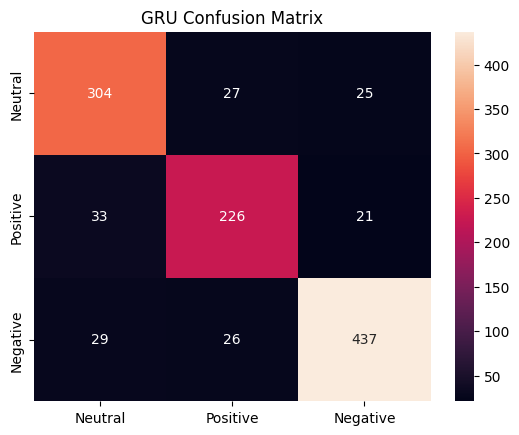

In [16]:
model_gru.load_state_dict(torch.load("models/gru_model.pt"))
model_gru.eval()
preds_gru, labels_gru = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_gru(inputs)
        preds_gru.extend(outputs.argmax(1).cpu().numpy())
        labels_gru.extend(labels.numpy())

acc_gru = accuracy_score(labels_gru, preds_gru)
prec_gru = precision_score(labels_gru, preds_gru, average='weighted')
rec_gru = recall_score(labels_gru, preds_gru, average='weighted')
f1_gru = f1_score(labels_gru, preds_gru, average='weighted')

print(f"GRU -> Acc: {acc_gru:.4f}, Prec: {prec_gru:.4f}, Rec: {rec_gru:.4f}, F1: {f1_gru:.4f}")
print(classification_report(labels_gru, preds_gru, target_names=['Neutral','Positive','Negative']))

cm_gru = confusion_matrix(labels_gru, preds_gru)
sns.heatmap(cm_gru, annot=True, fmt='d', xticklabels=['Neutral','Positive','Negative'], yticklabels=['Neutral','Positive','Negative'])
plt.title("GRU Confusion Matrix")
plt.savefig("results/cm_gru.png")
plt.show()

# **Fine‑tuning IndoBERT untuk Klasifikasi Sentimen**

In [17]:
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

tokenizer = AutoTokenizer.from_pretrained("indolem/indobert-base-uncased")

# Gunakan versi teks yang hanya di-lowercase tanpa stopword removal untuk BERT
def tokenize_fn(examples):
    return tokenizer(examples['bert_text'], padding='max_length', truncation=True, max_length=128)

train_hf = HfDataset.from_pandas(df_train[['bert_text','label']])
test_hf = HfDataset.from_pandas(df_test[['bert_text','label']])
train_hf = train_hf.map(tokenize_fn, batched=True)
test_hf = test_hf.map(tokenize_fn, batched=True)
train_hf = train_hf.rename_column('label', 'labels')
test_hf = test_hf.rename_column('label', 'labels')
train_hf.set_format('torch', columns=['input_ids','attention_mask','labels'])
test_hf.set_format('torch', columns=['input_ids','attention_mask','labels'])

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/4511 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

# **Trainer IndoBERT dengan Early Stopping**

In [19]:
model_bert = AutoModelForSequenceClassification.from_pretrained(
    "indolem/indobert-base-uncased", num_labels=3
).to(device)

training_args = TrainingArguments(
    output_dir="./models/indobert_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs/tensorboard/indobert",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted')
    }

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

start_bert = time.time()
trainer.train()
train_time_bert = time.time() - start_bert

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecat

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.686898,0.656281,0.714539,0.709152
2,0.516694,0.471556,0.806738,0.807378
3,0.341393,0.381112,0.857270,0.857992
4,0.266170,0.369339,0.873227,0.873361
5,0.201962,0.373632,0.879433,0.878914


Error during conversion: AttributeError("'str' object has no attribute 'decode'")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

# **Evaluasi IndoBERT & Simpan Model**

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

IndoBERT -> Acc: 0.8794, Prec: 0.8791, Rec: 0.8794, F1: 0.8789
              precision    recall  f1-score   support

     Neutral       0.88      0.85      0.86       356
    Positive       0.86      0.83      0.85       280
    Negative       0.89      0.93      0.91       492

    accuracy                           0.88      1128
   macro avg       0.88      0.87      0.87      1128
weighted avg       0.88      0.88      0.88      1128



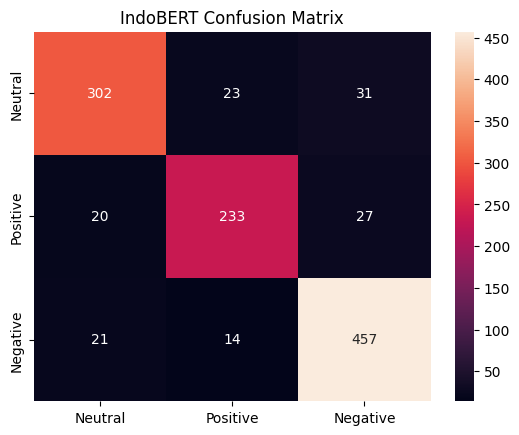

In [20]:
trainer.save_model("models/indobert_model")

preds = trainer.predict(test_hf)
preds_bert = np.argmax(preds.predictions, axis=-1)
labels_bert = preds.label_ids

acc_bert = accuracy_score(labels_bert, preds_bert)
prec_bert = precision_score(labels_bert, preds_bert, average='weighted')
rec_bert = recall_score(labels_bert, preds_bert, average='weighted')
f1_bert = f1_score(labels_bert, preds_bert, average='weighted')

print(f"IndoBERT -> Acc: {acc_bert:.4f}, Prec: {prec_bert:.4f}, Rec: {rec_bert:.4f}, F1: {f1_bert:.4f}")
print(classification_report(labels_bert, preds_bert, target_names=['Neutral','Positive','Negative']))

cm_bert = confusion_matrix(labels_bert, preds_bert)
sns.heatmap(cm_bert, annot=True, fmt='d', xticklabels=['Neutral','Positive','Negative'], yticklabels=['Neutral','Positive','Negative'])
plt.title("IndoBERT Confusion Matrix")
plt.savefig("results/cm_bert.png")
plt.show()

# **Tabel Perbandingan & Simpan Hasil**

In [21]:
comparison_df = pd.DataFrame({
    "Model": ["GRU + Attention", "IndoBERT (fine-tuned)"],
    "Accuracy": [acc_gru, acc_bert],
    "Precision": [prec_gru, prec_bert],
    "Recall": [rec_gru, rec_bert],
    "F1-Score": [f1_gru, f1_bert],
    "Training Time (s)": [train_time_gru, train_time_bert]
})
comparison_df.to_csv("results/comparison.csv", index=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,GRU + Attention,0.857270,0.857843,0.857270,0.857471,11.827763
1,IndoBERT (fine-tuned),0.879433,0.879137,0.879433,0.878914,638.429013


# **Visualisasi Perbandingan**

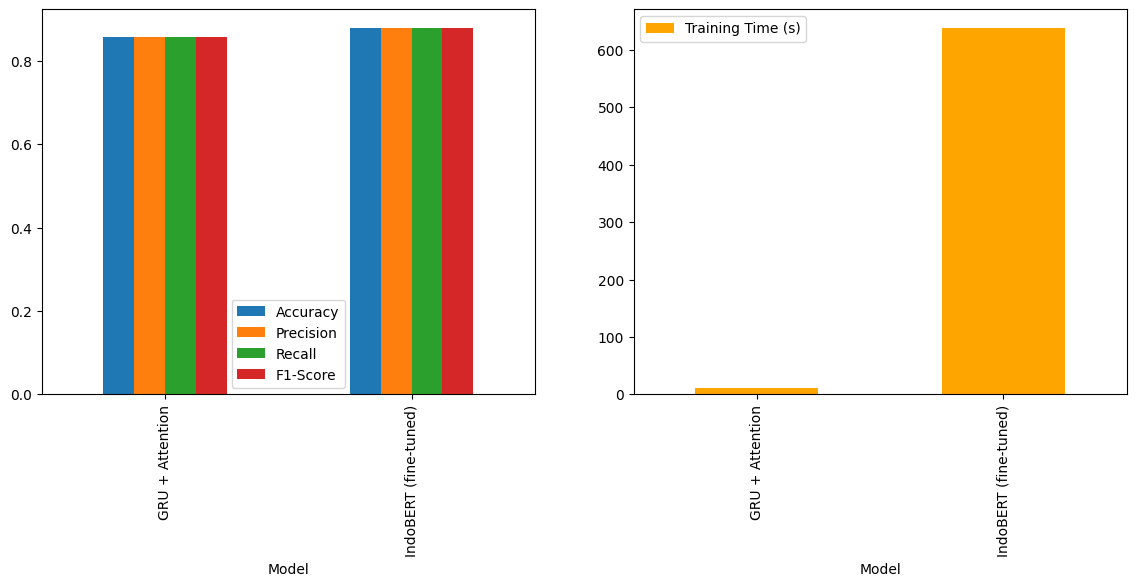

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
comparison_df.plot(x="Model", y=["Accuracy","Precision","Recall","F1-Score"], kind="bar", ax=axes[0])
comparison_df.plot(x="Model", y="Training Time (s)", kind="bar", ax=axes[1], color="orange")
plt.savefig("results/comparison_plot.png")
plt.show()

# **Function Inferensi GRU**

In [23]:
def predict_gru(text):
    """Prediksi sentimen dengan model GRU terlatih"""
    # Bersihkan teks
    cleaned = clean_text(text)

    # Encode
    encoded = encode_text(cleaned)
    input_tensor = torch.tensor([encoded], dtype=torch.long).to(device)

    # Prediksi
    model_gru.eval()
    with torch.no_grad():
        output = model_gru(input_tensor)
        prob = torch.softmax(output, dim=1).cpu().numpy()[0]
        pred = output.argmax(1).item()

    sentimen_map = {0: 'Netral', 1: 'Positif', 2: 'Negatif'}
    return sentimen_map[pred], prob

# **Function Inferensi IndoBERT**

In [24]:
# Load tokenizer dan model IndoBERT yang sudah di-fine-tune
tokenizer_bert_inf = AutoTokenizer.from_pretrained("models/indobert_model")
model_bert_inf = AutoModelForSequenceClassification.from_pretrained("models/indobert_model").to(device)

def predict_bert(text):
    """Prediksi sentimen dengan model IndoBERT terlatih"""
    # BERT hanya perlu lowercase
    text_lower = str(text).lower()

    # Tokenisasi
    inputs = tokenizer_bert_inf(text_lower, padding='max_length', truncation=True, max_length=128, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Prediksi
    model_bert_inf.eval()
    with torch.no_grad():
        output = model_bert_inf(**inputs)
        prob = torch.softmax(output.logits, dim=1).cpu().numpy()[0]
        pred = output.logits.argmax(1).item()

    sentimen_map = {0: 'Netral', 1: 'Positif', 2: 'Negatif'}
    return sentimen_map[pred], prob

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

# **Interface untuk Input Teks Bebas**

In [25]:
import ipywidgets as widgets
from IPython.display import display, clear_output

text_input = widgets.Textarea(
    value='',
    placeholder='Ketik komentar di sini...',
    description='Input:',
    layout=widgets.Layout(width='80%', height='100px')
)

predict_btn = widgets.Button(description='Prediksi Sentimen', button_style='primary')
output_panel = widgets.Output()

def on_predict_clicked(b):
    if text_input.value.strip() == '':
        with output_panel:
            clear_output()
            print("⚠️ Silakan masukkan teks terlebih dahulu.")
        return

    text = text_input.value.strip()

    # Prediksi dari kedua model
    sent_gru, prob_gru = predict_gru(text)
    sent_bert, prob_bert = predict_bert(text)

    with output_panel:
        clear_output()
        print("="*60)
        print(f"📝 Input: \"{text[:200]}{'...' if len(text)>200 else ''}\"")
        print("-"*60)
        print(f"🔵 GRU + Attention  → {sent_gru}")
        print(f"   Confidence: Netral={prob_gru[0]:.3f}, Positif={prob_gru[1]:.3f}, Negatif={prob_gru[2]:.3f}")
        print("-"*60)
        print(f"🟠 IndoBERT (fine-tuned) → {sent_bert}")
        print(f"   Confidence: Netral={prob_bert[0]:.3f}, Positif={prob_bert[1]:.3f}, Negatif={prob_bert[2]:.3f}")
        print("="*60)

predict_btn.on_click(on_predict_clicked)

display(widgets.VBox([text_input, predict_btn, output_panel]))

# **Uji Coba Otomatis**

In [26]:
# Contoh komentar uji
test_comments = [
    "Program MBG sangat membantu anak-anak di sekolah, terima kasih pemerintah!",
    "Korupsi besar-besaran di proyek MBG, uang rakyat dikorup oknum!",
    "Saya tidak tahu apa itu MBG, tidak ada di daerah saya.",
    "Makanan yang dikasih basi dan tidak layak, kasihan anak-anak.",
    "Semoga program ini bisa berjalan lancar dan tepat sasaran ke depannya.",
]

print("="*70)
print("UJI COBA INFERENSI DENGAN CONTOH KOMENTAR")
print("="*70)
for comment in test_comments:
    sent_gru, _ = predict_gru(comment)
    sent_bert, _ = predict_bert(comment)
    print(f"\n📝 \"{comment}\"")
    print(f"   GRU: {sent_gru}  |  IndoBERT: {sent_bert}")
print("\n" + "="*70)

UJI COBA INFERENSI DENGAN CONTOH KOMENTAR

📝 "Program MBG sangat membantu anak-anak di sekolah, terima kasih pemerintah!"
   GRU: Positif  |  IndoBERT: Netral

📝 "Korupsi besar-besaran di proyek MBG, uang rakyat dikorup oknum!"
   GRU: Negatif  |  IndoBERT: Netral

📝 "Saya tidak tahu apa itu MBG, tidak ada di daerah saya."
   GRU: Netral  |  IndoBERT: Netral

📝 "Makanan yang dikasih basi dan tidak layak, kasihan anak-anak."
   GRU: Negatif  |  IndoBERT: Netral

📝 "Semoga program ini bisa berjalan lancar dan tepat sasaran ke depannya."
   GRU: Positif  |  IndoBERT: Netral



# **Download Proyek**

In [27]:

from importlib.metadata import version

libs = ["transformers","datasets","torch","scikit-learn","matplotlib","seaborn","tqdm","pandas","numpy","tensorboard","nltk"]

with open("requirements.txt", "w") as f:
    for lib in libs:
        try:
            v = version(lib)
            f.write(f"{lib}=={v}\n")
        except Exception:
            pass  # library tidak ditemukan, lewati

print("requirements.txt telah dibuat.")

!zip -r /content/kode_sentimenAnalisis_mbg_V2.zip /content/models /content/results /content/logs /content/requirements.txt

requirements.txt telah dibuat.
  adding: content/models/ (stored 0%)
  adding: content/models/gru_model.pt (deflated 8%)
  adding: content/models/indobert_model/ (stored 0%)
  adding: content/models/indobert_model/training_args.bin (deflated 53%)
  adding: content/models/indobert_model/checkpoint-705/ (stored 0%)
  adding: content/models/indobert_model/checkpoint-705/rng_state.pth (deflated 26%)
  adding: content/models/indobert_model/checkpoint-705/training_args.bin (deflated 53%)
  adding: content/models/indobert_model/checkpoint-705/trainer_state.json (deflated 77%)
  adding: content/models/indobert_model/checkpoint-705/scheduler.pt (deflated 61%)
  adding: content/models/indobert_model/checkpoint-705/config.json (deflated 55%)
  adding: content/models/indobert_model/checkpoint-705/optimizer.pt (deflated 23%)
  adding: content/models/indobert_model/checkpoint-705/model.safetensors (deflated 7%)
  adding: content/models/indobert_model/config.json (deflated 55%)
  adding: content/mode

FileNotFoundError: Cannot find file: /content/kode_sentimenAnalisis_V2.zip

# **Mount Drive untuk Simpan zip**

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
#Save ke Google Drive
!cp kode_sentimenAnalisis_mbg_V2.zip /content/drive/MyDrive/